# ThermalTwin — Weather-Only Model Comparison

This notebook mirrors [`05_sample_notebook.ipynb`](05_sample_notebook.ipynb), but for the `*_weather_only` model family (`LinearWeatherOnlyPredictor`, `RidgeWeatherOnlyPredictor`, `NeuralWeatherOnlyPredictor`).

Instead of the flat, lag-column feature matrix used by the `*_one_step` models, these models consume a windowed `(samples, timesteps, features)` history of weather-only signals and predict a multi-step-ahead horizon of indoor temperature.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils.data_loader import NetatmoDataLoader
from utils.feature_engineer import FeatureEngineer
from utils.windowing import make_windows
from utils.split import DatasetSplitter
from utils.metrics import compute_metrics

from models.linear_weather_only import LinearWeatherOnlyPredictor
from models.ridge_weather_only import RidgeWeatherOnlyPredictor
from models.neural_weather_only import NeuralWeatherOnlyPredictor

2026-07-16 10:28:13.575052: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-16 10:28:13.602515: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-16 10:28:13.602558: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-16 10:28:13.603636: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-16 10:28:13.610635: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-16 10:28:13.611519: I tensorflow/core/platform/cpu_feature_guard.cc:1

## 1. Load Data

Uses the same station as the one-step comparison notebook.

In [2]:
DATA_DIR = Path("../data/csv")
STATION = "Huis_19_06_2026_all"

loader = NetatmoDataLoader(DATA_DIR)
df = loader.load_station(STATION)

df.head()

,datetime,temp_in,hum_in,temp_out,hum_out
0,2026-05-19 00:02:30,20.1,57,11.1,75.0
1,2026-05-19 00:07:30,20.1,56,11.0,75.0
2,2026-05-19 00:12:30,20.1,56,11.0,75.0
3,2026-05-19 00:17:30,20.1,56,11.0,75.0
4,2026-05-19 00:22:30,20.1,56,10.9,75.0


## 2. Time Features

The weather-only family doesn't use `FeatureEngineer`'s lag columns or shifted target — only its cyclical time-of-day / time-of-year features, since the temporal structure here comes from the sliding window itself.

In [3]:
engineer = FeatureEngineer()

df_time = engineer.create_time_features(df)
df_time.head()

,datetime,temp_in,hum_in,temp_out,hum_out,hour,minute,hour_sin,hour_cos,dayofyear,day_sin,day_cos
0,2026-05-19 00:02:30,20.1,57,11.1,75.0,0,2,0.0,1.0,139,0.681972,-0.731378
1,2026-05-19 00:07:30,20.1,56,11.0,75.0,0,7,0.0,1.0,139,0.681972,-0.731378
2,2026-05-19 00:12:30,20.1,56,11.0,75.0,0,12,0.0,1.0,139,0.681972,-0.731378
3,2026-05-19 00:17:30,20.1,56,11.0,75.0,0,17,0.0,1.0,139,0.681972,-0.731378
4,2026-05-19 00:22:30,20.1,56,10.9,75.0,0,22,0.0,1.0,139,0.681972,-0.731378


## 3. Build the Windowed Dataset

`make_windows` slides a `LOOKBACK`-step window of weather features across the series and pairs it with the next `HORIZON` steps of indoor temperature.

In [4]:
FEATURE_COLUMNS = ["temp_out", "hum_out", "hour_sin", "hour_cos", "day_sin", "day_cos"]
TARGET_COLUMN = "temp_in"

LOOKBACK = 48  # 4 hours of history at 5-minute resolution
HORIZON = 12   # predict the next hour (12 x 5 minutes)

X, y = make_windows(
    df_time,
    feature_columns=FEATURE_COLUMNS,
    target_column=TARGET_COLUMN,
    lookback=LOOKBACK,
    horizon=HORIZON,
)

print(X.shape)
print(y.shape)

(8859, 48, 6)
(8859, 12)


## 4. Train / Validation / Test Split

`DatasetSplitter` splits chronologically and works the same way on these windowed ndarrays as it does on the DataFrames in the one-step notebook.

In [5]:
splitter = DatasetSplitter()

(
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
) = splitter.split(X, y)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(6201, 48, 6)
(1329, 48, 6)
(1329, 48, 6)


## 5. Train and Compare Weather-Only Models

Same pattern as the one-step notebook: all three models share the `BasePredictor` interface, so one loop trains them all — the sklearn-based models ignore the neural-network-only kwargs.

In [6]:
models = {
    "Linear": LinearWeatherOnlyPredictor(),
    "Ridge": RidgeWeatherOnlyPredictor(alpha=1.0),
    "Neural": NeuralWeatherOnlyPredictor(
        lookback=LOOKBACK,
        n_features=len(FEATURE_COLUMNS),
        horizon=HORIZON,
    ),
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train, X_val, y_val, epochs=30, batch_size=64, verbose=0)

2026-07-16 10:28:17.425273: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-07-16 10:28:17.434606: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Training Linear...
Training Ridge...
Training Neural...


## 6. Evaluate

MAE/RMSE are computed over the flattened `(samples, horizon)` predictions, giving one overall error number per model.

In [7]:
results = []
predictions = {}

for name, model in models.items():
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)

    val_mae, val_rmse = compute_metrics(y_val.flatten(), y_val_pred.flatten())
    test_mae, test_rmse = compute_metrics(y_test.flatten(), y_test_pred.flatten())

    results.append({
        "model": name,
        "val_mae": val_mae,
        "val_rmse": val_rmse,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
    })

    predictions[name] = y_test_pred

results_df = pd.DataFrame(results).set_index("model")

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [8]:
results_df

NameError: name 'results_df' is not defined

## 7. Visualize Results

In [9]:
results_df[["test_mae", "test_rmse"]].plot(kind="bar", figsize=(8, 5))

plt.title("Test set error by model (averaged across the horizon)")
plt.ylabel("°C")
plt.xticks(rotation=0)
plt.show()

NameError: name 'results_df' is not defined

Multi-step forecasts typically degrade the further ahead they predict — worth looking at directly rather than only the averaged number above.

/tmp/ipykernel_1206/3179941202.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


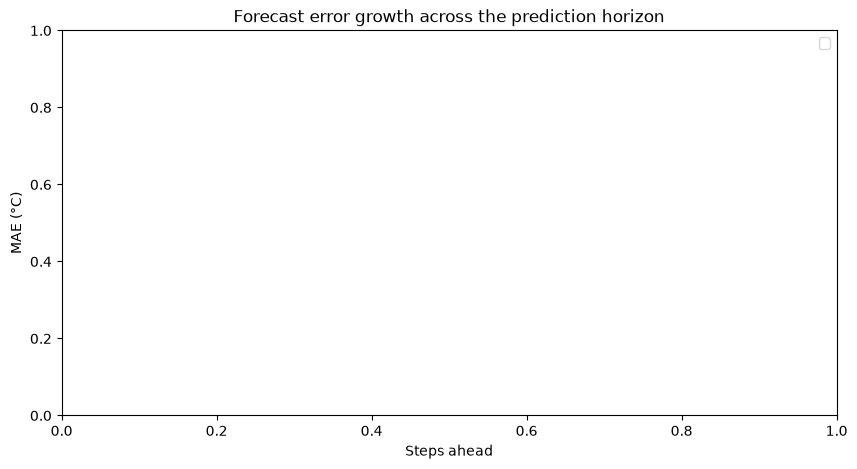

In [10]:
plt.figure(figsize=(10, 5))

for name, pred in predictions.items():
    step_mae = np.mean(np.abs(pred - y_test), axis=0)
    plt.plot(range(1, HORIZON + 1), step_mae, marker="o", label=name)

plt.xlabel("Steps ahead")
plt.ylabel("MAE (°C)")
plt.title("Forecast error growth across the prediction horizon")
plt.legend()
plt.show()

Finally, a single example window from the test set, actual vs. predicted for each step of the horizon.

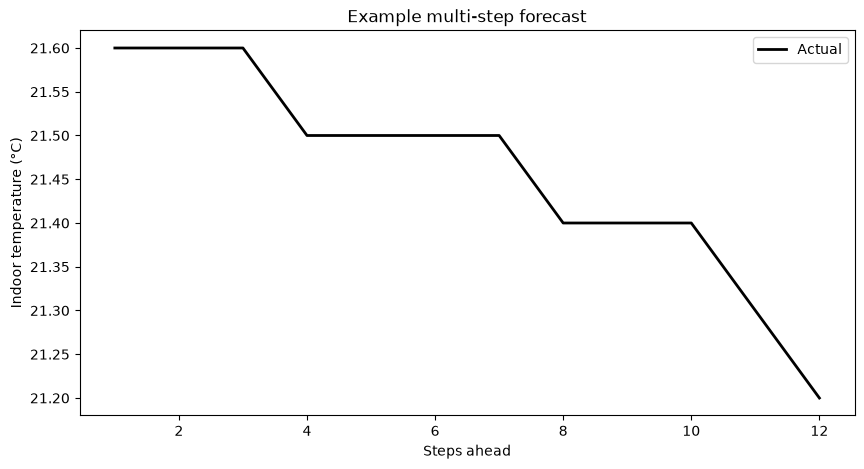

In [11]:
sample_idx = 0

plt.figure(figsize=(10, 5))
plt.plot(range(1, HORIZON + 1), y_test[sample_idx], label="Actual", color="black", linewidth=2)

for name, pred in predictions.items():
    plt.plot(range(1, HORIZON + 1), pred[sample_idx], label=name, alpha=0.8, marker="o")

plt.xlabel("Steps ahead")
plt.ylabel("Indoor temperature (°C)")
plt.title("Example multi-step forecast")
plt.legend()
plt.show()